In [2]:
%matplotlib inline

minimum point: [ 2. -1.]
function value: 1.9854434192102064e-17
iterations: 39


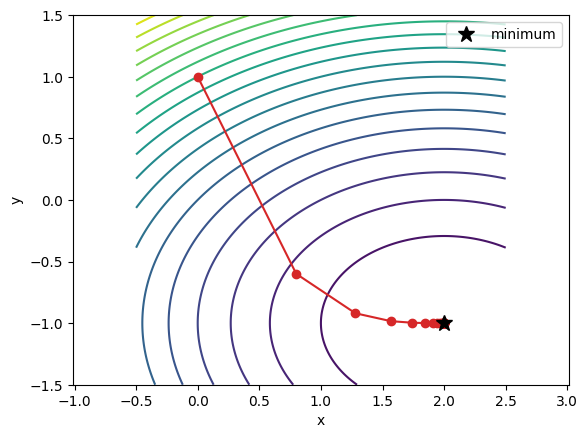

In [7]:
import numpy as np
import matplotlib.pyplot as plt


def objective(x,y):
    """F(x, y) = (x - 2)^2 + 2(y + 1)^2"""
    return (x - 2.0)**2 + 2.0*(y + 1.0)**2

def gradient(x, y):
    return np.array([
        2.0*(x - 2.0),
        4.0*(y + 1.0),
    ])


def gradient_descent(grad, x0, alpha=0.2, tol=1e-8, max_iter=1000):
    x = np.asarray(x0, dtype=float).copy()
    history = [x.copy()]

    for iteration in range(max_iter):
        g = grad(x[0],x[1])

        if np.linalg.norm(g) < tol:
            return x, np.array(history), iteration

        x = x - alpha*g
        history.append(x.copy())

    raise RuntimeError("최대 반복 횟수 안에 수렴하지 않았습니다.")

x_min, history, n_iter = gradient_descent(
    gradient,
    x0=[0.0, 1.0],
    alpha=0.2,
)
f_history=objective(history[:,0],history[:,1])

print("minimum point:", x_min)
print("function value:", objective(*x_min))
print("iterations:", n_iter)

x_grid = np.linspace(-0.5, 2.5, 200)
y_grid = np.linspace(-1.5, 1.5, 200)
X, Y = np.meshgrid(x_grid, y_grid)
Z = (X - 2.0)**2 + 2.0*(Y + 1.0)**2

plt.contour(X, Y, Z, levels=20)
plt.plot(history[:, 0], history[:, 1], "o-", color="tab:red")

plt.plot(2.0, -1.0, "k*", markersize=12, label="minimum")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

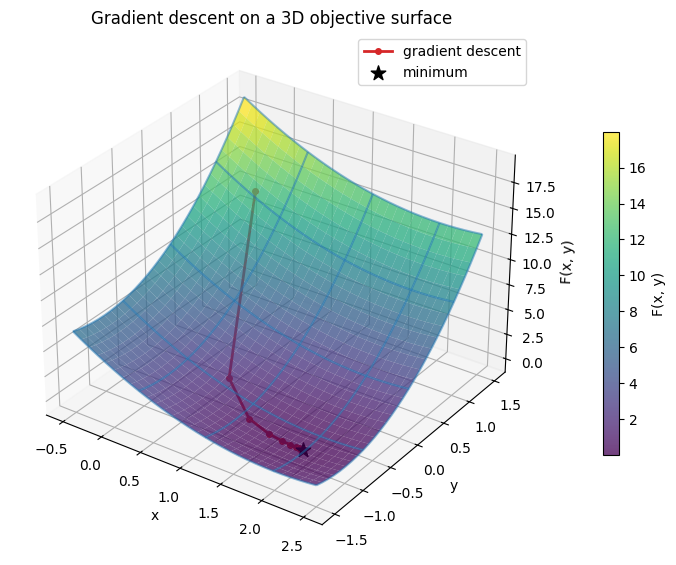

In [ ]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

# 목적함수의 3차원 곡면
surface = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    alpha=0.75,
    edgecolor="none",
)
ax.plot_wireframe(X, Y, Z, rstride=8, cstride=8,
                  color="tab:blue", alpha=0.5)


# 각 반복점에서의 함수값
z_history = np.array([objective(*point) for point in history])

# 곡면에 가려지지 않도록 경로를 조금 위에 표시한다.
z_offset = 0.02*Z.max()
ax.plot(
    history[:, 0],
    history[:, 1],
    z_history + z_offset,
    "o-",
    color="tab:red",
    linewidth=2,
    markersize=4,
    label="gradient descent",
)

ax.scatter(2.0, -1.0, z_offset, color="black", marker="*", s=120,
           label="minimum")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("F(x, y)")
ax.set_title("Gradient descent on a 3D objective surface")
ax.view_init(elev=30, azim=-55)
fig.colorbar(surface, ax=ax, shrink=0.6, pad=0.1, label="F(x, y)")
ax.legend()
plt.show()
#fig.savefig('/tmp/GradientDescent_ex.png')